# Pose augmentation with left/right keypoint remapping

`sv.KeyPoints.xy` has a fixed row order: row 1 is always `left_eye`, row 2 is always `right_eye`, and so on for every left/right pair in the skeleton. A horizontal flip mirrors *coordinates*, but on its own it does nothing about *row order* — after mirroring, the position that used to hold the left eye is now where the right eye visually is, but row 1 is still labeled `left_eye`.

This notebook builds a small, deterministic pose (no model or dataset needed), flips it with [Albumentations](https://albumentations.ai/)' `HorizontalFlip`, and shows the fix: after mirroring coordinates, also swap each left/right pair's row so the label matches the mirrored side. [AlbumentationsX](https://github.com/albumentations-team/AlbumentationsX)'s `KeypointParams(label_mapping=...)` automates exactly this swap inside the transform for larger pipelines — doing it explicitly here shows what that option is doing under the hood.

In [1]:
import albumentations as A
import cv2
import numpy as np
import supervision as sv

C:\Users\sktam\AppData\Local\Temp\ccwork\svenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## A deterministic pose

17 points in COCO order — the order `sv.KeyPoints.from_ultralytics`, `from_inference`, and RF-DETR's pose models already return. The pose has one arm raised so a wrong flip is visibly different from a correct one, not just numerically.

In [2]:
COCO_KEYPOINT_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
]

# (left_index, right_index) for every mirrored pair.
LEFT_RIGHT_PAIRS = [
    (1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (11, 12), (13, 14), (15, 16),
]

IMAGE_WIDTH, IMAGE_HEIGHT = 400, 400

# right arm raised: an asymmetric pose so a naive flip is visibly wrong.
POSE = np.array([
    [200, 60],   # nose
    [190, 50], [210, 50],       # left_eye, right_eye
    [180, 55], [220, 55],       # left_ear, right_ear
    [170, 120], [230, 120],     # left_shoulder, right_shoulder
    [160, 180], [260, 90],      # left_elbow, right_elbow (raised)
    [150, 230], [280, 50],      # left_wrist, right_wrist (raised)
    [180, 220], [220, 220],     # left_hip, right_hip
    [175, 300], [225, 300],     # left_knee, right_knee
    [170, 370], [230, 370],     # left_ankle, right_ankle
], dtype=np.float32)

key_points = sv.KeyPoints(xy=POSE[np.newaxis, :, :], class_id=np.array([0]))

## Flip the coordinates

`A.HorizontalFlip` mirrors each `(x, y)` pair. It has no idea which row is semantically left or right, so row order is untouched — this is the naive result the issue describes.

In [3]:
transform = A.Compose(
    [A.HorizontalFlip(p=1.0)],
    keypoint_params=A.KeypointParams(format="xy", remove_invisible=False),
)

blank_image = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH, 3), dtype=np.uint8)
mirrored = transform(image=blank_image, keypoints=key_points.xy[0].tolist())
mirrored_xy = np.array(mirrored["keypoints"], dtype=np.float32)

# Rebuilt straight from the mirrored coordinates: coordinates are correct,
# but row order still says row 1 is "left_eye" even though its mirrored
# position is now on the visual right of the frame.
naive_flip = sv.KeyPoints(xy=mirrored_xy[np.newaxis, :, :], class_id=np.array([0]))

## Fix: swap each pair's row after mirroring

This is the step AlbumentationsX's `KeypointParams(label_mapping=...)` automates. Doing it by hand here: build the permutation once from `LEFT_RIGHT_PAIRS`, then rebuild `sv.KeyPoints` with that row order applied to the mirrored coordinates.

In [4]:
remap = list(range(len(COCO_KEYPOINT_NAMES)))
for left, right in LEFT_RIGHT_PAIRS:
    remap[left], remap[right] = remap[right], remap[left]

correct_flip = sv.KeyPoints(
    xy=mirrored_xy[remap][np.newaxis, :, :], class_id=np.array([0])
)

## Verify

For every pair, the remapped left row should sit exactly where the *original* right row mirrors to, and vice versa. Albumentations mirrors pixel index `i` to `(width - 1 - i)`, so that's the formula to check against rather than a bare `width - x`.

In [5]:
MIRROR_X = IMAGE_WIDTH - 1

for left, right in LEFT_RIGHT_PAIRS:
    expected_left = [MIRROR_X - POSE[right][0], POSE[right][1]]
    assert np.allclose(correct_flip.xy[0][left], expected_left), COCO_KEYPOINT_NAMES[left]

    expected_right = [MIRROR_X - POSE[left][0], POSE[left][1]]
    assert np.allclose(correct_flip.xy[0][right], expected_right), COCO_KEYPOINT_NAMES[right]

# And confirm the naive version actually is wrong for this asymmetric pose,
# not just differently-labeled-but-coincidentally-equal:
assert not np.allclose(naive_flip.xy[0][9], correct_flip.xy[0][9])

print("All left/right pairs land where they should.")

All left/right pairs land where they should.


## See the difference

Left-side joints in blue, right-side in red. Watch the raised arm: in "naive flip" it's still colored red ("right") even though mirroring put it on the visual left — exactly the bug. In "correct flip" it's blue, matching its true anatomical side after the mirror.

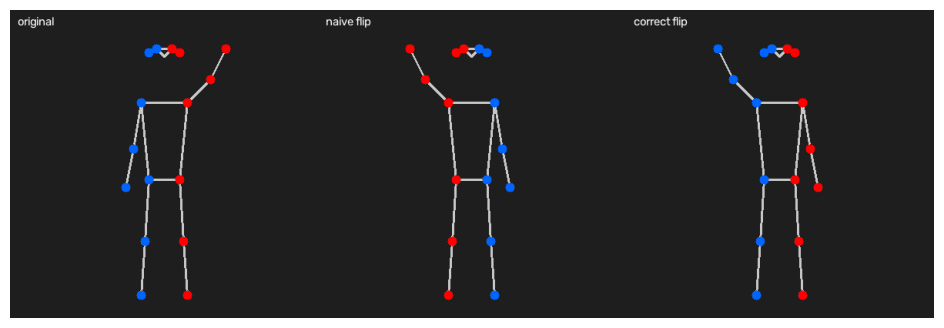

In [6]:
LEFT_INDICES = {left for left, _ in LEFT_RIGHT_PAIRS}
RIGHT_INDICES = {right for _, right in LEFT_RIGHT_PAIRS}


def render(key_points: sv.KeyPoints, canvas: np.ndarray) -> np.ndarray:
    scene = sv.EdgeAnnotator(color=sv.Color(200, 200, 200), thickness=2).annotate(
        canvas.copy(), key_points
    )

    num_points = key_points.xy.shape[1]
    left_mask = np.array([[i in LEFT_INDICES for i in range(num_points)]])
    right_mask = np.array([[i in RIGHT_INDICES for i in range(num_points)]])

    left_kp = sv.KeyPoints(xy=key_points.xy, class_id=key_points.class_id, visible=left_mask)
    right_kp = sv.KeyPoints(xy=key_points.xy, class_id=key_points.class_id, visible=right_mask)

    scene = sv.VertexAnnotator(color=sv.Color(0, 100, 255), radius=6).annotate(scene, left_kp)
    scene = sv.VertexAnnotator(color=sv.Color(255, 0, 0), radius=6).annotate(scene, right_kp)
    return scene


panels = [
    ("original", key_points),
    ("naive flip", naive_flip),
    ("correct flip", correct_flip),
]
canvas = np.full((IMAGE_HEIGHT, IMAGE_WIDTH, 3), 30, dtype=np.uint8)
images = [render(kp, canvas) for _, kp in panels]
combined = np.concatenate(images, axis=1)
for i, (title, _) in enumerate(panels):
    cv2.putText(
        combined, title, (i * IMAGE_WIDTH + 10, 20),
        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA,
    )

sv.plot_image(combined, size=(12, 4))